<a href="https://colab.research.google.com/github/rddelarosa/DSC1105/blob/main/FA_2_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
library(tidyverse) # Load library
cy_tof <- read.csv("/content/cytof_one_experiment.csv") # Load file

In [3]:
head(cy_tof)

,NKp30,KIR3DL1,NKp44,KIR2DL1,GranzymeB,CXCR6,CD161,KIR2DS4,NKp46,NKG2D,⋯,CD16,TNFa,ILT2,Perforin,KIR2DL2.L3.S2,KIR2DL3,NKG2A,NTB.A,CD56,INFg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.1875955,3.6156932,-0.5605694,-0.2936654,2.477893,-0.14470053,-0.3152872,1.94497046,4.0818316,2.6200784,⋯,3.9951417,0.90143498,-0.386027758,6.431983,1.22710292,2.660657999,-0.5220613,4.348923,2.897523,-0.3841108
2,1.0348518,1.7001820,-0.2889611,-0.4798280,3.261016,-0.03392447,-0.4112129,3.80251714,3.7339299,-0.4832788,⋯,4.4082309,1.93590153,2.983874845,6.814827,-0.04141081,3.841304627,4.6771149,3.474335,3.782870,2.7186296
3,2.9996398,6.1411419,1.9032606,0.4823102,4.277562,1.94654156,-0.5022347,-0.32010171,4.5594631,-0.5069090,⋯,6.0023244,-0.02336999,-0.521099944,5.099562,-0.16705075,-0.009694396,-0.4730573,5.634341,5.701186,2.5321763
4,4.2998594,-0.2211586,0.2425707,-0.4831267,3.351808,0.92622195,3.8772370,-0.16969487,4.4831486,1.9272290,⋯,5.8238698,-0.60793749,-0.043783559,5.841797,-0.51753289,-0.592990887,-0.4059049,4.598021,6.065672,2.4564582
5,-0.4386448,-0.5035892,-0.1526320,0.7506128,3.194145,-0.05893640,1.0907379,-0.05033025,0.8379358,-0.4581674,⋯,4.0122501,-0.61989100,1.182703288,4.888777,-0.36251589,-0.398123704,-0.5440881,3.606101,1.966169,3.1470092
6,2.0883050,-0.3992646,3.4550676,-0.5200856,4.345102,-0.36434277,-0.5705891,-0.45033591,4.0550848,3.4283565,⋯,-0.5832926,0.14311030,-0.003258955,3.952542,-0.20194392,-0.202592720,3.8882776,2.346275,6.473243,2.8282987


For the first set of questions, we will look again at the CyTOF data Download CyTOF data. Each row in the dataset represents a cell, and each column in the dataset represents a protein, and the value is element i, j of the dataset represents the amount of protein j in cell i.



1. Use pivot_longer to reshape the dataset into one that has two columns, the first giving the protein identity and the second giving the amount of the protein in one of the cells. The dataset you get should have 1750000 rows (50000 cells in the original dataset times 35 proteins).


In [4]:
# Reshape the dataset
cy_tof_pivot <- cy_tof %>%
  pivot_longer(
    cols = everything(),
    names_to = "protein_identity",
    values_to = "amount")

# Verify the dimensions
print(dim(cy_tof_pivot))

# Preview the first few rows
slice_head(cy_tof_pivot, n=36)

[1] 296975      2


protein_identity,amount
<chr>,<dbl>
NKp30,0.1875955
KIR3DL1,3.6156932
NKp44,-0.5605694
KIR2DL1,-0.2936654
GranzymeB,2.4778929
CXCR6,-0.1447005
CD161,-0.3152872
KIR2DS4,1.9449705
NKp46,4.0818316


2. Use group_by and summarise to find the median protein level and the median absolute deviation of the protein level for each marker. (Use the R functions median and mad).


In [5]:
# Group the protein
cy_tof_summ <- cy_tof_pivot %>%
  group_by (protein_identity) %>%
  summarise(
    mean_protein = mean(amount, na.rm = TRUE),
    mad_protein= mad(amount, na.rm = TRUE)
         )
head(cy_tof_summ)


protein_identity,mean_protein,mad_protein
<chr>,<dbl>,<dbl>
CD107a,0.4796275,0.4988429
CD16,4.8564578,0.9116033
CD161,1.0756499,1.6680391
CD2,3.3046732,1.8184007
CD4,0.2907984,0.3948092
CD56,5.6571133,1.0356159


3. Make a plot with MAD on the x-axis and median on the y-axis. This is known as a spreadlocation (s-l) plot. What does it tell you about the relationship betwen the median and the MAD?



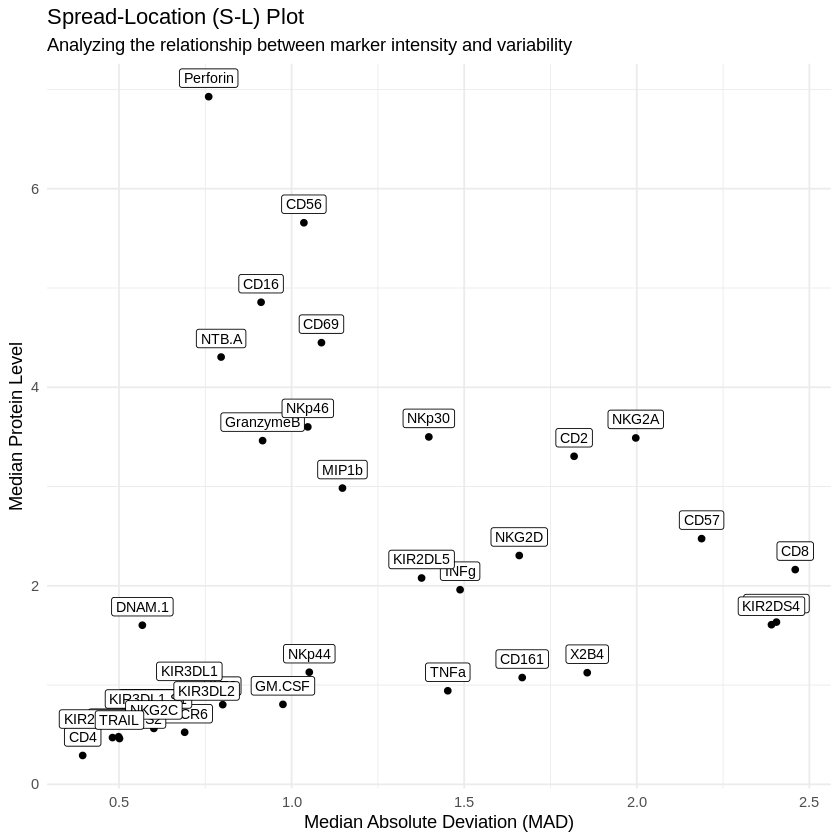

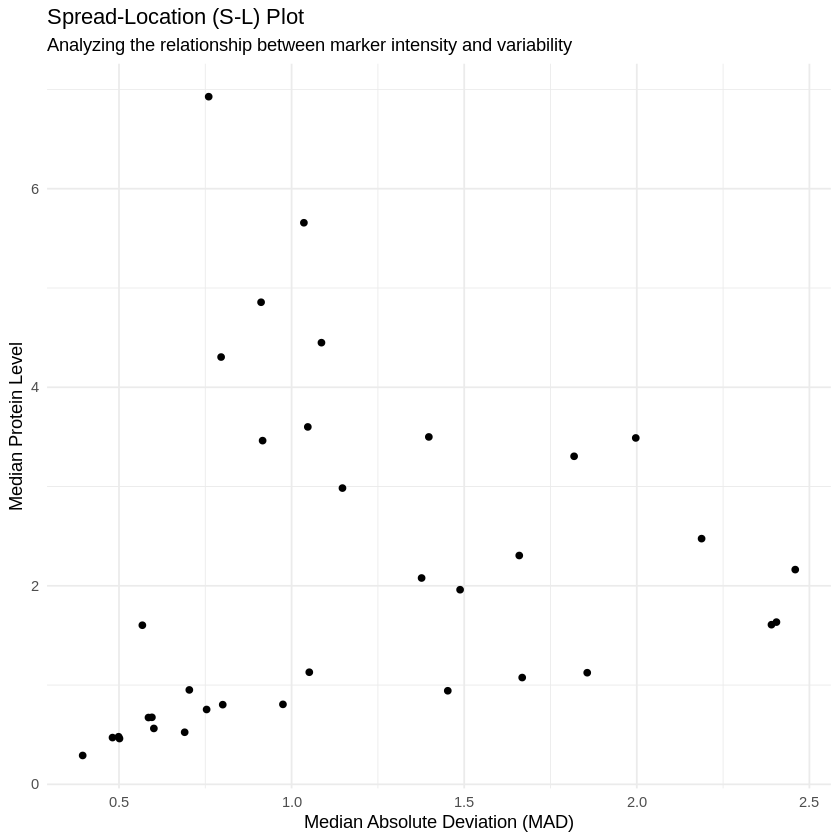

In [6]:
# Create plot
ggplot(cy_tof_summ, aes(x=mad_protein, y=mean_protein)) +
    geom_point() +
    theme_minimal() +
    geom_label(aes(label = protein_identity), size = 3, vjust = -0.5) +
    labs(
      title = "Spread-Location (S-L) Plot",
      x = "Median Absolute Deviation (MAD)",
      y = "Median Protein Level",
      subtitle = "Analyzing the relationship between marker intensity and variability"
    )

ggplot(cy_tof_summ, aes(x=mad_protein, y=mean_protein)) +
    geom_point() +
    theme_minimal() +
    labs(
      title = "Spread-Location (S-L) Plot",
      x = "Median Absolute Deviation (MAD)",
      y = "Median Protein Level",
      subtitle = "Analyzing the relationship between marker intensity and variability"
    )



The spread-location plot shows a weak correlation between protein intensity and variability, indicating that the data transformation successfully stabilized variance across different expression levels. Markers with high medians and low MAD values represent stable lineage proteins consistent across the population, while those with high MAD values identify the specific markers driving biological heterogeneity. Ultimately, this independent relationship confirms that the differences captured in the data reflect true cellular diversity rather than technical artifacts proportional to signal strength.

Next, for more practice pivoting, we will look at a dataset from dcldata. Install the package dcldata using

install.packages("remotes")
remotes::install_github("dcl-docs/dcldata")

(you don’t need the first line if the remotes package is already installed).

Load the package using library(dcldata).

Load the dataset example_gymnastics_2 using the command data(example_gymnastics_2). Notice that the column names are of the form event_year.





In [7]:
# Install dcldata from GitHub
remotes::install_github("dcl-docs/dcldata")

# Load the libraries
library(dcldata)

# Load the dataset
data(example_gymnastics_2)

head(example_gymnastics_2)

── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpecBauS/remotesa278305719/dcl-docs-dcldata-0a08cbb/DESCRIPTION’ ... OK
* preparing ‘dcldata’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘dcldata_0.1.2.9000.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



country,vault_2012,floor_2012,vault_2016,floor_2016
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
United States,48.132,45.366,46.866,45.999
Russia,46.366,41.599,45.733,42.032
China,44.266,40.833,44.332,42.066


4. Using either pivot_longer on its own or pivot_longer in combination with separate, reshape the dataset so that it has columns for country, event, year, and score.


In [8]:
gym_pivot <- example_gymnastics_2 %>%
  pivot_longer(
    cols = -country,                # Pivot every column except country
    names_to = c("event", "year"),
    names_sep = "_",
    values_to = "score"             # The actual values go into 'score'
  )

head(gym_pivot)

country,event,year,score
<chr>,<chr>,<chr>,<dbl>
United States,vault,2012,48.132
United States,floor,2012,45.366
United States,vault,2016,46.866
United States,floor,2016,45.999
Russia,vault,2012,46.366
Russia,floor,2012,41.599
